In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

In [4]:
GAMBIT_RANDOM = "../data/gambit-output/gambit-random-v5-lh-21984853/FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "../data/gambit-output/gambit-diver-v5-gm2-21984859/FS_MSSM7atQ_diver_gambit.hdf5"
MODELGEN = "../data/modelgen-output/modelgen-v5/SP_MSSM7atQ_random_modelgen.hdf5"

In [6]:
scan_gambit_random = h5py.File(GAMBIT_RANDOM, 'r')["MSSM"]
scan_gambit_diver = h5py.File(GAMBIT_DIVER, 'r')["MSSM"]
scan_modelgen = h5py.File(MODELGEN, 'r')["MSSM"]

mask =       scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1
lnL_gm2_gr = scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2"][mask]
gm2_gr =     scan_gambit_random["#muon_gm2 @PrecisionBit::GM2C_SUSY::central"][mask]
mask =       scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1
lnL_gm2_gd = scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2"][mask]
gm2_gd =     scan_gambit_diver["#muon_gm2 @PrecisionBit::GM2C_SUSY::central"][mask]
mask =       scan_modelgen["GM2_gmuon"][:] != -1
gm2_mg =     scan_modelgen["GM2_gmuon"][mask]


## g-2 Likelihood

The Likelihood in GAMBIT is calculated for $a_\mu = 1/2 \cdot (g-2)$ as a Gaussian Likelihood

$$
\mathcal{L}_{G}(x|\mu) = \frac{1}{\sqrt{2 \pi} \sigma} \mathrm{exp} \left[-\frac{1}{2} \frac{(x - \mu)^2}{\sigma^2}\right]
$$

In [7]:
def gaussian(x: float, mu: float, sigma: float, sigma_e: float) -> float:
    """profiled Gaussian Likelihood"""
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-0.5 * ((x - mu) **2 / (sigma + sigma_e **2)))

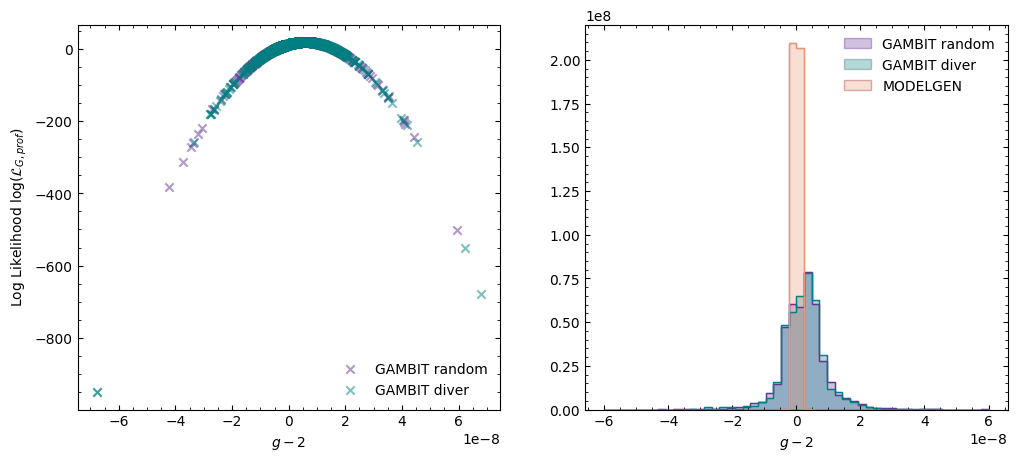

In [11]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.scatter(gm2_gr, lnL_gm2_gr, color='rebeccapurple', marker='x', alpha=0.5, label="GAMBIT random")
ax1.scatter(gm2_gd, lnL_gm2_gd, color='teal', marker='x', alpha=0.5, label="GAMBIT diver")

ax1.set_xlabel("$g - 2$")
ax1.set_ylabel("Log Likelihood $\\mathrm{log}(\\mathcal{L}_{G, prof})$")
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax1.legend(frameon=False)

ax2.hist(gm2_gr, bins=50, range=(-6e-8, 6e-8), density=True, facecolor='rebeccapurple', alpha=0.3, label="GAMBIT random", histtype='stepfilled', edgecolor='indigo')
ax2.hist(gm2_gd, bins=50, range=(-6e-8, 6e-8), density=True, facecolor='teal', alpha=0.3, label="GAMBIT diver", histtype='stepfilled', edgecolor='darkslategrey')
ax2.hist(gm2_mg, bins=50, range=(-6e-8, 6e-8), density=True, facecolor='darksalmon', alpha=0.3, label="MODELGEN", histtype='stepfilled', edgecolor='maroon')
ax2.hist(gm2_gr, bins=50, range=(-6e-8, 6e-8), density=True, histtype='step', edgecolor='rebeccapurple')
ax2.hist(gm2_gd, bins=50, range=(-6e-8, 6e-8), density=True, histtype='step', edgecolor='teal')
ax2.hist(gm2_mg, bins=50, range=(-6e-8, 6e-8), density=True, histtype='step', edgecolor='darksalmon')
ax2.set_xlabel("$g - 2$")
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.legend(frameon=False)




plt.show()